# 분석 단계별 프로세스 - Isolation Forest 이상 탐지

`03_xgboost.ipynb` / `04_catboost.ipynb`와 **같은 데이터셋·분할·피크 정의**(`peak_dataset.csv`, `peak_experiment_meta.json`)를 재사용하되, Isolation Forest는 그 둘과 **동일한 역할의 모델이 아니다**.

```
Supervised Peak Risk Classification (RF / XGBoost / CatBoost)
        vs
Unsupervised Anomaly Detection (Isolation Forest)
```

이 노트북의 목적은 정상 제조 패턴만 보고 이상을 탐지하는 비지도 방식이, 라벨이 있는 현재 데이터에서 기존 supervised 모델 대비 어떤 위치에 있는지 **실제 수치로** 확인하는 것이다. 피크 위험 라벨은 Isolation Forest 학습에는 전혀 사용하지 않고, **평가**(validation contamination 선택, test 최종 평가)에만 사용한다.

## 1. 라이브러리 / 설정

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

sns.set(style="darkgrid")
plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

실험 설정. `PEAK_QUANTILE`은 03/04와 같아야 한다 (같은 라벨 기준으로 평가하기 위함). `CONTAMINATION_GRID`는 validation에서만 비교하고, test의 실제 양성 비율은 어떤 방식으로도 들여다보지 않는다. `IF_PARAMS`는 `contamination`을 제외한 나머지 IsolationForest 하이퍼파라미터를 고정값으로 관리한다.

In [2]:
SEED = 42
PEAK_QUANTILE = 0.90

RESULTS_DIR = Path("../results")

# validation F1으로만 선택한다. test 양성 비율은 절대 참고하지 않는다.
CONTAMINATION_GRID = [0.01, 0.03, 0.05, 0.10]

# contamination을 제외한 하이퍼파라미터는 고정한다.
IF_PARAMS = dict(n_estimators=300, max_samples="auto", max_features=1.0, random_state=SEED)

## 2. 03/04 산출물 불러오기

In [3]:
meta = json.loads((RESULTS_DIR / "peak_experiment_meta.json").read_text())
dataset = pd.read_csv(RESULTS_DIR / "peak_dataset.csv", index_col="Date", parse_dates=True)
baseline_proba = pd.read_csv(RESULTS_DIR / "peak_baseline_probabilities.csv", index_col="Date", parse_dates=True)
catboost_pred = pd.read_csv(RESULTS_DIR / "catboost_predictions.csv", index_col="Date", parse_dates=True)

FEATURES = meta["features"]
assert PEAK_QUANTILE == meta["peak_quantile"], "03/04를 같은 PEAK_QUANTILE로 먼저 실행해야 한다"
assert list(dataset.columns) == FEATURES + ["target_power", "split"]

print(f"dataset {dataset.shape}, features={len(FEATURES)}")

dataset (6000, 32), features=30


## 3. 시계열 분할 / Target 정의

분할은 03/04와 동일하다.

| 구간 | 기간 |
|---|---|
| Train | 2021-01-08 ~ 2021-07-31 |
| Validation | 2021-08-01 ~ 2021-08-31 |
| Test | 2021-09-01 ~ 2021-09-14 |

`y_train` / `y_val` / `y_test`는 **Isolation Forest 학습에 사용하지 않는다.** validation에서 contamination을 고르고, test에서 최종 평가할 때만 사용하는 ground truth다.

In [4]:
train_df = dataset.loc[dataset["split"] == "train"]
val_df = dataset.loc[dataset["split"] == "validation"]
test_df = dataset.loc[dataset["split"] == "test"]

assert train_df.index.max() < val_df.index.min() <= val_df.index.max() < test_df.index.min()
assert val_df.index.min() == pd.Timestamp(meta["val_start"]) and test_df.index.min() == pd.Timestamp(meta["test_start"])

peak_threshold = float(train_df["target_power"].quantile(PEAK_QUANTILE))
assert peak_threshold == meta["peak_threshold"], "03/04와 피크 임계값이 다름"
print(f"peak threshold = {peak_threshold:.1f} (train {PEAK_QUANTILE:.0%} quantile)")

y_train = (train_df["target_power"] >= peak_threshold).astype(int)
y_val = (val_df["target_power"] >= peak_threshold).astype(int)
y_test = (test_df["target_power"] >= peak_threshold).astype(int)

label_summary = pd.DataFrame(
    {
        "samples": [len(y_train), len(y_val), len(y_test)],
        "positive": [y_train.sum(), y_val.sum(), y_test.sum()],
        "negative": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    },
    index=["Train", "Validation", "Test"],
).assign(positive_ratio=lambda t: (t["positive"] / t["samples"]).round(4))
label_summary

peak threshold = 179.0 (train 90% quantile)


,samples,positive,negative,positive_ratio
Train,4920,505,4415,0.1026
Validation,744,101,643,0.1358
Test,336,47,289,0.1399


### 3-1. 데이터 누수 점검

03/04에서 이미 확인한 항목을 다시 확인한다.
- `lag_1`이 직전 시점의 `target_power`와 같은지 (= 행 T의 feature가 T-1 이하 정보인지)
- target과 동일한 feature가 없는지

In [5]:
prev_power = dataset["target_power"].shift(1)
contiguous = dataset.index.to_series().diff() == pd.Timedelta(hours=1)
assert (dataset.loc[contiguous, "lag_1"] == prev_power[contiguous]).all(), "lag_1 != power(t-1)"

identical = [c for c in FEATURES if np.array_equal(dataset[c].to_numpy(), dataset["target_power"].to_numpy())]
assert not identical, identical
print("누수 점검 통과 - feature에 target 정보 없음")

누수 점검 통과 - feature에 target 정보 없음


## 4. Feature 구성

미래 정보나 target leakage가 없는 30개 feature(`meta["features"]`)를 그대로 사용한다. 현재/미래 `target_power`는 feature에 포함하지 않는다.

Isolation Forest는 tree 기반이라 scaling이 필수는 아니지만, raw feature와 `StandardScaler` feature 두 방식을 모두 만들어 validation에서 비교한다.

In [6]:
X_train = train_df[FEATURES]
X_val = val_df[FEATURES]
X_test = test_df[FEATURES]

scaler = StandardScaler().fit(X_train)
X_train_sc = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=FEATURES)
X_val_sc = pd.DataFrame(scaler.transform(X_val), index=X_val.index, columns=FEATURES)
X_test_sc = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=FEATURES)

print(f"raw: {X_train.shape}, scaled: {X_train_sc.shape}")

raw: (4920, 30), scaled: (4920, 30)


## 5. 평가 함수 / Isolation Forest 헬퍼

`IsolationForest.predict()`는 `1 = inlier(정상)`, `-1 = outlier(이상)`을 반환하므로 평가용으로 `0 = 정상`, `1 = 이상`으로 변환한다.

`decision_function()`은 값이 **클수록 정상**이므로, "값이 클수록 위험"이 되도록 부호를 반전한다: `risk_score = -model.decision_function(X)`.

Precision/Recall/F1은 양성 클래스(피크=1) 기준이고, ROC-AUC/PR-AUC는 `risk_score`로 계산한다.

In [7]:
def fit_isolation_forest(X_fit: pd.DataFrame, contamination: float) -> IsolationForest:
    return IsolationForest(contamination=contamination, **IF_PARAMS).fit(X_fit)


def anomaly_and_score(model: IsolationForest, X: pd.DataFrame):
    anomaly_flag = (model.predict(X) == -1).astype(int)  # -1(outlier) -> 1(이상), 1(inlier) -> 0(정상)
    risk_score = -model.decision_function(X)  # decision_function: 클수록 정상 -> 부호 반전해 클수록 위험
    return anomaly_flag, risk_score


def evaluate(y_true, anomaly_flag, risk_score) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, anomaly_flag, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(y_true, anomaly_flag),
        "Precision": precision_score(y_true, anomaly_flag, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, anomaly_flag, pos_label=1, zero_division=0),
        "F1": f1_score(y_true, anomaly_flag, pos_label=1, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, risk_score),
        "PR-AUC": average_precision_score(y_true, risk_score),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

## 6. 실험 A - 전체 train 데이터로 비지도 학습 (기본 실험)

label을 전혀 보지 않고 train 전체로 학습한다. `raw` / `scaled` feature, `CONTAMINATION_GRID` 조합을 모두 validation에서 평가해 F1이 가장 높은 조합을 고른다. **test는 여기서 전혀 사용하지 않는다.**

In [8]:
stageA = []
for feature_name, (X_fit, X_eval) in {
    "raw": (X_train, X_val),
    "scaled": (X_train_sc, X_val_sc),
}.items():
    for contamination in CONTAMINATION_GRID:
        model = fit_isolation_forest(X_fit, contamination)
        anomaly_val, score_val = anomaly_and_score(model, X_eval)
        stageA.append({
            "feature": feature_name,
            "contamination": contamination,
            **evaluate(y_val, anomaly_val, score_val),
        })

stageA = pd.DataFrame(stageA)
stageA.round(4)

,feature,contamination,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
0,raw,0.01,0.8669,0.5714,0.0792,0.1391,0.6088,0.2675,8,6,93,637
1,raw,0.03,0.8575,0.4194,0.1287,0.1970,0.6088,0.2675,13,18,88,625
2,raw,0.05,0.8468,0.3774,0.1980,0.2597,0.6088,0.2675,20,33,81,610
3,raw,0.10,0.7500,0.2185,0.3267,0.2619,0.6088,0.2675,33,118,68,525
4,scaled,0.01,0.8669,0.5714,0.0792,0.1391,0.6088,0.2675,8,6,93,637
5,scaled,0.03,0.8575,0.4194,0.1287,0.1970,0.6088,0.2675,13,18,88,625
6,scaled,0.05,0.8468,0.3774,0.1980,0.2597,0.6088,0.2675,20,33,81,610
7,scaled,0.10,0.7500,0.2185,0.3267,0.2619,0.6088,0.2675,33,118,68,525


In [9]:
best_by_feature = stageA.loc[stageA.groupby("feature")["F1"].idxmax()].set_index("feature")
display(best_by_feature[["contamination", "Precision", "Recall", "F1", "PR-AUC"]].round(4))

f1_gap = abs(best_by_feature.loc["raw", "F1"] - best_by_feature.loc["scaled", "F1"])
# validation 결과가 거의 같으면(F1 차이 < 0.01) 더 단순한 raw feature를 유지한다.
BEST_FEATURE = "raw" if f1_gap < 0.01 else best_by_feature["F1"].idxmax()
BEST_CONTAMINATION = float(best_by_feature.loc[BEST_FEATURE, "contamination"])

print(f"raw vs scaled 최고 F1 차이 = {f1_gap:.4f}")
print(f"선택: feature={BEST_FEATURE}, contamination={BEST_CONTAMINATION} (실험 A, validation F1 기준)")

,contamination,Precision,Recall,F1,PR-AUC
feature,,,,,
raw,0.1,0.2185,0.3267,0.2619,0.2675
scaled,0.1,0.2185,0.3267,0.2619,0.2675


raw vs scaled 최고 F1 차이 = 0.0000
선택: feature=raw, contamination=0.1 (실험 A, validation F1 기준)


## 7. 실험 B - 정상 데이터만으로 학습 (참고, semi-supervised)

Train 중 기존 피크 라벨 기준 **정상(`y_train == 0`) 데이터만** 골라 학습한다. 이 방식은 label을 학습 데이터 "선정"에 사용하므로 A와 달리 순수 비지도가 아니다 — **참고용 비교 실험**이며 기본 실험(A)을 대체하지 않는다.

In [10]:
train_normal = {"raw": X_train.loc[y_train == 0], "scaled": X_train_sc.loc[y_train == 0]}

stageB = []
for feature_name, X_fit in train_normal.items():
    X_eval = X_val if feature_name == "raw" else X_val_sc
    for contamination in CONTAMINATION_GRID:
        model = fit_isolation_forest(X_fit, contamination)
        anomaly_val, score_val = anomaly_and_score(model, X_eval)
        stageB.append({
            "feature": feature_name,
            "contamination": contamination,
            **evaluate(y_val, anomaly_val, score_val),
        })

stageB = pd.DataFrame(stageB)
best_by_feature_B = stageB.loc[stageB.groupby("feature")["F1"].idxmax()].set_index("feature")
display(best_by_feature_B[["contamination", "Precision", "Recall", "F1", "PR-AUC"]].round(4))

BEST_FEATURE_B = best_by_feature_B["F1"].idxmax()
BEST_CONTAMINATION_B = float(best_by_feature_B.loc[BEST_FEATURE_B, "contamination"])
print(f"실험 B validation 최고: feature={BEST_FEATURE_B}, contamination={BEST_CONTAMINATION_B}")

,contamination,Precision,Recall,F1,PR-AUC
feature,,,,,
raw,0.05,0.4239,0.3861,0.4041,0.378
scaled,0.05,0.4239,0.3861,0.4041,0.378


실험 B validation 최고: feature=raw, contamination=0.05


## 8. 최종 모델 (실험 A) 학습

In [11]:
FINAL_X_TRAIN = X_train if BEST_FEATURE == "raw" else X_train_sc
FINAL_X_VAL = X_val if BEST_FEATURE == "raw" else X_val_sc
FINAL_X_TEST = X_test if BEST_FEATURE == "raw" else X_test_sc

if_model = fit_isolation_forest(FINAL_X_TRAIN, BEST_CONTAMINATION)
if_val_anomaly, if_val_score = anomaly_and_score(if_model, FINAL_X_VAL)
if_test_anomaly, if_test_score = anomaly_and_score(if_model, FINAL_X_TEST)

print(f"최종 모델(실험 A): feature={BEST_FEATURE}, contamination={BEST_CONTAMINATION}, params={IF_PARAMS}")
print("validation:", {k: round(v, 4) if isinstance(v, float) else v for k, v in evaluate(y_val, if_val_anomaly, if_val_score).items()})

최종 모델(실험 A): feature=raw, contamination=0.1, params={'n_estimators': 300, 'max_samples': 'auto', 'max_features': 1.0, 'random_state': 42}
validation: {'Accuracy': 0.75, 'Precision': 0.2185, 'Recall': 0.3267, 'F1': 0.2619, 'ROC-AUC': 0.6088, 'PR-AUC': 0.2675, 'TP': np.int64(33), 'FP': np.int64(118), 'FN': np.int64(68), 'TN': np.int64(525)}


## 9. Test 평가 - RF / XGBoost / CatBoost / Isolation Forest

RF/XGBoost는 03에서 저장한 확률·threshold, CatBoost는 04에서 저장한 예측을 그대로 쓴다(재학습 없음). Isolation Forest는 실험 A의 validation 선택 contamination을 그대로 test에 적용한다 — **test 라벨은 여기서 처음이자 마지막으로 확인한다.**

Isolation Forest는 supervised 분류기가 아니므로 확률 threshold가 아니라 학습 시 정한 contamination이 곧 판정 기준이다. 아래 표의 `threshold` 컬럼은 RF/XGBoost/CatBoost는 분류 확률 threshold, Isolation Forest는 contamination 값을 의미한다.

In [12]:
test_baseline = baseline_proba.loc[baseline_proba["split"] == "test"]
assert test_baseline.index.equals(test_df.index)
assert catboost_pred.index.equals(test_df.index)


def evaluate_proba(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return evaluate(y_true, pred, proba)


test_eval = {
    "Random Forest": evaluate_proba(y_test, test_baseline["rf_probability"].to_numpy(), meta["rf_threshold"]),
    "XGBoost": evaluate_proba(y_test, test_baseline["xgb_probability"].to_numpy(), meta["xgb_threshold"]),
    "CatBoost": evaluate(y_test, catboost_pred["predicted_label"].to_numpy(), catboost_pred["risk_probability"].to_numpy()),
    "Isolation Forest": evaluate(y_test, if_test_anomaly, if_test_score),
}

METRIC_COLS = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "TP", "FP", "FN", "TN"]
comparison_df = pd.DataFrame(test_eval).T[METRIC_COLS]
comparison_df.round(4)

,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
Random Forest,0.6190,0.8298,0.7091,0.9553,0.7371,39.0,24.0,8.0,265.0
XGBoost,0.6066,0.7872,0.6852,0.9533,0.7113,37.0,24.0,10.0,265.0
CatBoost,0.6481,0.7447,0.6931,0.9590,0.7575,35.0,19.0,12.0,270.0
Isolation Forest,0.5000,0.1064,0.1754,0.7126,0.2908,5.0,5.0,42.0,284.0


### 9-1. 실제 피크 위험 탐지율 / 오탐

- 실제 피크 위험(양성) 중 몇 %를 Isolation Forest가 탐지했는가 = Recall
- 정상 데이터를 얼마나 오탐했는가 = FP / (FP + TN)

In [13]:
if_row = test_eval["Isolation Forest"]
if_fpr = if_row["FP"] / (if_row["FP"] + if_row["TN"])
print(f"Isolation Forest - 실제 피크 위험 탐지율(Recall): {if_row['Recall']:.2%}")
print(f"Isolation Forest - 정상 데이터 오탐율(FPR): {if_fpr:.2%}")
print(f"참고 - CatBoost Recall: {test_eval['CatBoost']['Recall']:.2%}, XGBoost Recall: {test_eval['XGBoost']['Recall']:.2%}")

Isolation Forest - 실제 피크 위험 탐지율(Recall): 10.64%
Isolation Forest - 정상 데이터 오탐율(FPR): 1.73%
참고 - CatBoost Recall: 74.47%, XGBoost Recall: 78.72%


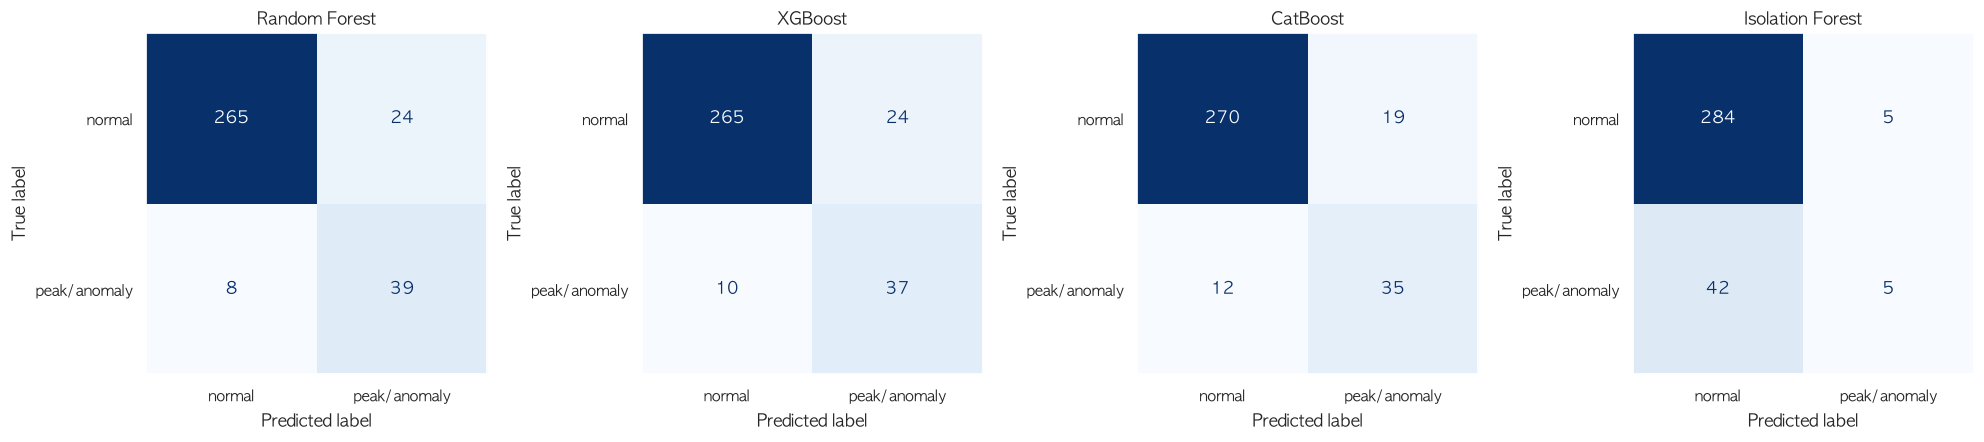

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, row) in zip(axes, test_eval.items()):
    if name == "Random Forest":
        pred = (test_baseline["rf_probability"].to_numpy() >= meta["rf_threshold"]).astype(int)
    elif name == "XGBoost":
        pred = (test_baseline["xgb_probability"].to_numpy() >= meta["xgb_threshold"]).astype(int)
    elif name == "CatBoost":
        pred = catboost_pred["predicted_label"].to_numpy()
    else:
        pred = if_test_anomaly
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred, labels=[0, 1]),
        display_labels=["normal", "peak/anomaly"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 10. 시각화

- Anomaly score 분포 (정상 vs 실제 피크위험)
- 실제 피크위험 vs anomaly score 시계열 (test 구간)

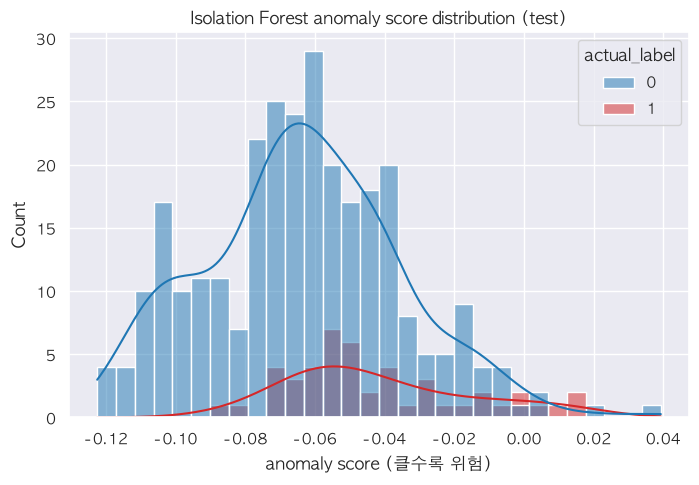

In [15]:
score_df = pd.DataFrame({"anomaly_score": if_test_score, "actual_label": y_test.to_numpy()}, index=test_df.index)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=score_df, x="anomaly_score", hue="actual_label", bins=30, kde=True, ax=ax,
             palette={0: "tab:blue", 1: "tab:red"})
ax.set_title("Isolation Forest anomaly score distribution (test)")
ax.set_xlabel("anomaly score (클수록 위험)")
plt.show()

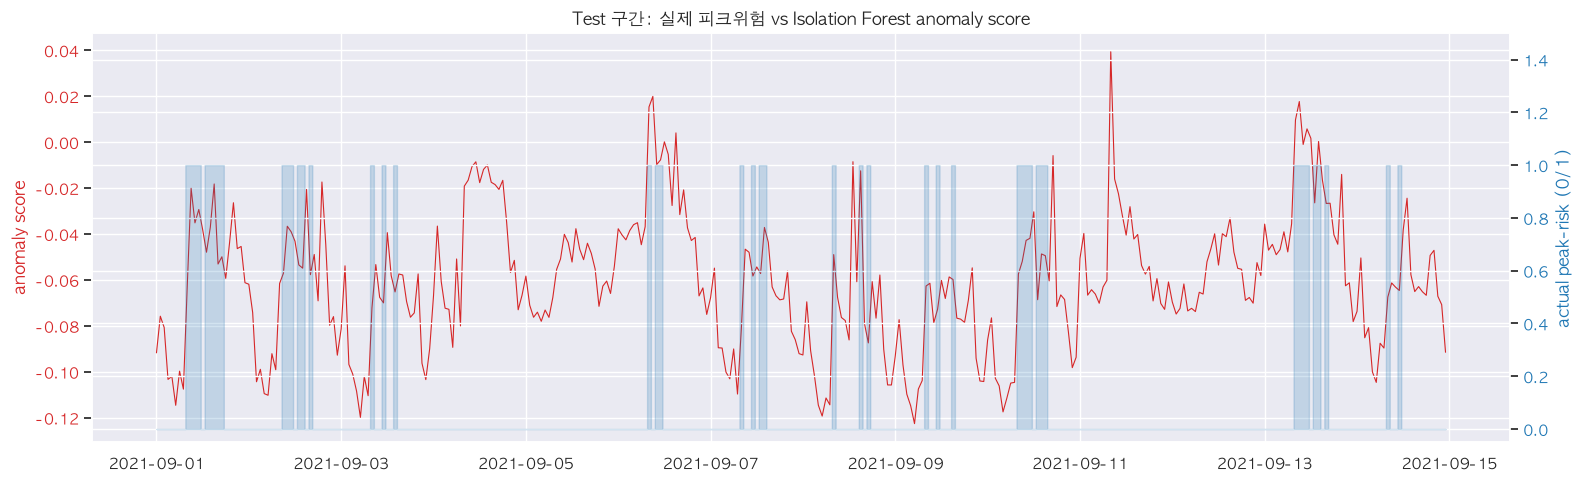

In [16]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(score_df.index, score_df["anomaly_score"], color="tab:red", linewidth=0.8, label="anomaly score")
ax1.set_ylabel("anomaly score", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.fill_between(score_df.index, score_df["actual_label"], step="mid", alpha=0.2, color="tab:blue", label="actual peak-risk")
ax2.set_ylabel("actual peak-risk (0/1)", color="tab:blue")
ax2.set_ylim(-0.05, 1.5)
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Test 구간: 실제 피크위험 vs Isolation Forest anomaly score")
fig.tight_layout()
plt.show()

## 11. Supervised Model과 비교

| 모델 | 방식 |
|---|---|
| Random Forest | supervised classification |
| XGBoost | supervised classification |
| CatBoost | supervised classification |
| Isolation Forest | **unsupervised anomaly detection** |

RF/XGBoost/CatBoost는 라벨을 직접 학습해 "피크 확률"을 추정하는 분류기이고, Isolation Forest는 라벨을 보지 않고 "정상 패턴에서 얼마나 벗어났는가"만 계산한다. 위 비교표의 숫자가 비슷하더라도 **동일한 역할의 모델로 해석하지 않는다.**

## 12. 최종 판단

In [17]:
positive_ratio_train = y_train.mean()
supervised_best_f1 = max(test_eval["Random Forest"]["F1"], test_eval["XGBoost"]["F1"], test_eval["CatBoost"]["F1"])
if_f1 = test_eval["Isolation Forest"]["F1"]

print(f"Train 양성 비율            : {positive_ratio_train:.2%}")
print(f"Supervised 모델 중 최고 F1 : {supervised_best_f1:.4f}")
print(f"Isolation Forest F1        : {if_f1:.4f} (차이 {if_f1 - supervised_best_f1:+.4f})")
print(f"Isolation Forest Recall    : {test_eval['Isolation Forest']['Recall']:.2%} vs supervised 최고 Recall {max(test_eval['Random Forest']['Recall'], test_eval['XGBoost']['Recall'], test_eval['CatBoost']['Recall']):.2%}")

Train 양성 비율            : 10.26%
Supervised 모델 중 최고 F1 : 0.7091
Isolation Forest F1        : 0.1754 (차이 -0.5337)
Isolation Forest Recall    : 10.64% vs supervised 최고 Recall 82.98%


판단 기준별 실제 결과:
- **양성 label이 매우 적은가?** -> train 양성 비율 10.26%. 극단적으로 희소하지는 않다 (supervised 학습에 charge 문제가 될 정도는 아님).
- **supervised 모델이 학습하기 어려운 수준인가?** -> 아니다. RF/XGBoost/CatBoost 모두 test F1 0.69~0.71대로 이미 준수하게 학습된다.
- **Isolation Forest의 Recall/F1이 경쟁력이 있는가?** -> 아니다. test F1 0.1754로 supervised 최고(0.7091) 대비 -0.53 이상 열세이고, Recall도 10.64%로 supervised 최저(74.47%)의 1/7 수준이다. contamination을 validation 최적값(0.10)으로 골랐음에도 실제 피크의 89%를 놓친다.
- **label 없이도 이상을 탐지할 필요가 있는가?** -> 아니다. 현재 피크 정의(라벨)가 이미 존재하고 안정적으로 갱신되므로 비지도 방식의 이점(라벨 불필요)이 실질적인 이득으로 이어지지 않는다.

**결론**: 비지도 이상탐지 baseline으로 사용했으나, 라벨이 존재하는 현재 데이터에서는 supervised boosting 모델(XGBoost/CatBoost)이 더 적합했다. Isolation Forest는 최종 모델 후보에 포함하지 않는다.

## 13. 결과 저장

In [18]:
isolation_forest_predictions = pd.DataFrame(
    {
        "Date": test_df.index,
        "actual_label": y_test.to_numpy(),
        "predicted_anomaly": if_test_anomaly,
        "anomaly_score": if_test_score,
        "actual_power": test_df["target_power"].to_numpy(),
    }
)
isolation_forest_predictions.to_csv(RESULTS_DIR / "isolation_forest_predictions.csv", index=False)

previous = pd.read_csv(RESULTS_DIR / "model_comparison.csv", index_col="Model")
previous = previous.loc[~previous.index.str.startswith("Isolation Forest")]

if_summary = evaluate(y_test, if_test_anomaly, if_test_score)
if_row_name = f"Isolation Forest (unsupervised, contamination={BEST_CONTAMINATION})"
# threshold 컬럼: Isolation Forest는 확률 threshold가 아니라 contamination 값을 의미한다.
if_row = pd.DataFrame({if_row_name: {"threshold": BEST_CONTAMINATION, **if_summary}}).T[previous.columns]

model_comparison = pd.concat([previous, if_row])
model_comparison.index.name = "Model"
model_comparison.to_csv(RESULTS_DIR / "model_comparison.csv")
model_comparison.astype(float).round(4)

,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
Model,,,,,,,,,,,
Persistence (lag_1 ≥ peak),179.00,0.8452,0.4468,0.4468,0.4468,0.8623,0.5295,21.0,26.0,26.0,263.0
Random Forest @0.5,0.50,0.9048,0.6190,0.8298,0.7091,0.9553,0.7371,39.0,24.0,8.0,265.0
XGBoost default (no spw) @0.5,0.50,0.9048,0.6471,0.7021,0.6735,0.9561,0.7417,33.0,18.0,14.0,271.0
XGBoost default (spw) @0.5,0.50,0.8988,0.5915,0.8936,0.7119,0.9567,0.7473,42.0,29.0,5.0,260.0
XGBoost tuned @0.5,0.50,0.9018,0.6000,0.8936,0.7179,0.9533,0.7113,42.0,28.0,5.0,261.0
XGBoost tuned @0.65,0.65,0.8988,0.6066,0.7872,0.6852,0.9533,0.7113,37.0,24.0,10.0,265.0
CatBoost @0.5,0.50,0.8958,0.5833,0.8936,0.7059,0.9590,0.7575,42.0,30.0,5.0,259.0
CatBoost @0.8,0.80,0.9077,0.6481,0.7447,0.6931,0.9590,0.7575,35.0,19.0,12.0,270.0
"Isolation Forest (unsupervised, contamination=0.1)",0.10,0.8601,0.5000,0.1064,0.1754,0.7126,0.2908,5.0,5.0,42.0,284.0


## 14. 최종 요약

In [19]:
summary_lines = [
    f"Peak threshold              : {peak_threshold:.1f}  (train {PEAK_QUANTILE:.0%} quantile)",
    f"Positive ratio               : train {y_train.mean():.2%} | validation {y_val.mean():.2%} | test {y_test.mean():.2%}",
    "",
    f"Isolation Forest feature      : {BEST_FEATURE}",
    f"Isolation Forest contamination: {BEST_CONTAMINATION} (validation F1 기준 선택)",
    f"Test에서 탐지된 anomaly 수     : {int(if_test_anomaly.sum())} / {len(if_test_anomaly)}",
    "",
    f"Isolation Forest  - Precision {test_eval['Isolation Forest']['Precision']:.4f}, Recall {test_eval['Isolation Forest']['Recall']:.4f}, "
    f"F1 {test_eval['Isolation Forest']['F1']:.4f}, PR-AUC {test_eval['Isolation Forest']['PR-AUC']:.4f}",
    f"XGBoost F1        : {test_eval['XGBoost']['F1']:.4f}",
    f"CatBoost F1       : {test_eval['CatBoost']['F1']:.4f}",
    "",
    "Random Forest / XGBoost / CatBoost = supervised classification",
    "Isolation Forest                   = unsupervised anomaly detection (동일한 역할의 모델로 해석하지 않음)",
    "",
    "최종 판단: Isolation Forest는 최종 모델 후보에서 제외. 라벨이 존재하는 현재 데이터에서는 supervised boosting 모델(XGBoost/CatBoost)이 더 적합하다.",
]
print("\n".join(summary_lines))

Peak threshold              : 179.0  (train 90% quantile)
Positive ratio               : train 10.26% | validation 13.58% | test 13.99%

Isolation Forest feature      : raw
Isolation Forest contamination: 0.1 (validation F1 기준 선택)
Test에서 탐지된 anomaly 수     : 10 / 336

Isolation Forest  - Precision 0.5000, Recall 0.1064, F1 0.1754, PR-AUC 0.2908
XGBoost F1        : 0.6852
CatBoost F1       : 0.6931

Random Forest / XGBoost / CatBoost = supervised classification
Isolation Forest                   = unsupervised anomaly detection (동일한 역할의 모델로 해석하지 않음)

최종 판단: Isolation Forest는 최종 모델 후보에서 제외. 라벨이 존재하는 현재 데이터에서는 supervised boosting 모델(XGBoost/CatBoost)이 더 적합하다.
